In [3]:
import numpy as np
import xarray as xr
import pandas as pd
import os
# plottng
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

import matplotlib.patheffects as pe

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import palettable.colorbrewer as cb 


from PIL import Image
import io

import scipy
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy import signal
from scipy.signal import welch
from statsmodels.tsa.stattools import ccf
from amocatlas import read

from process_raw_data import MHT_selection, MHT_lat_selection, lowpass_filter #, calc_ci

from stats_plots import acf_calc_plot, integral_time_scale, critical_r, plot_hovmöller, plot_crosscorr, plot_crosscorr_gif, plot_timeseries, plot_shifted_timeseries, lagged_std, zero_lag_corr

ModuleNotFoundError: No module named 'process_raw_data'

In [ ]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})

In [ ]:
ds = read.calafat2025()

lats = ds.LATITUDE.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats][1:]


MHT_dict = MHT_selection(ds, statistics=True, anomalies=True, time_mean=True, drop65=True)

lats = MHT_dict["lats"]
mht = MHT_dict["MHT"] 
mht_stats = MHT_dict["MHT_statistics"] 
mht_mean = mht_stats["mean"] # this is mean over posterior samples!
mht_time_mean = mht_stats["time_mean"]
mht_all_mean = mht_time_mean.mean(dim="posterior_samples")

mht_std = mht_stats["std"]
mht_ci = mht_stats["ci"]

# mht_anom = MHT_dict["MHT_anom"]
# choose one lat: 
lat_sel = 5
MHT_lat = MHT_lat_selection(MHT_dict, lat=lat_sel, ci=90, anomalies=True)

mht_lat = MHT_lat["MHT_lat"]
mht_lat_stats = MHT_lat["MHT_lat_statistics"] 
mht_lat_mean = MHT_lat["MHT_lat_statistics"]["mean"]
mht_lat_time_mean = MHT_lat["MHT_lat_statistics"]["time_mean"]



Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available



## process data
1. Remove seasonal cycle (deseasonalize) 
2. Remove linear trend 
3. Apply 4-quarter low-pass filter
4. Then do correlation/lead-lag analysis

In [ ]:
## 1. deseaosonalize

seasonal_clim = mht_mean.groupby('TIME.quarter').mean(dim='TIME')  # shape: (12, lat)
seasonal_clim_prob = mht.groupby('TIME.quarter').mean(dim='TIME')  # shape: (12, lat, posterior_samples)
# subtract it from each timestep
mht_anom = mht_mean.groupby('TIME.quarter') - seasonal_clim
mht_anom_prob = mht.groupby('TIME.quarter') - seasonal_clim_prob

## 2. remove linear trend
def detrend_dataset(ds):
    return xr.apply_ufunc(
        signal.detrend, ds, kwargs={"axis": -1},
        input_core_dims=[["TIME"]],
        output_core_dims=[["TIME"]]
    )
anom_dt = detrend_dataset(mht_anom)
anom_dt_prob = detrend_dataset(mht_anom_prob)
mht_dt = detrend_dataset(mht_mean)
mht_dt_prob = detrend_dataset(mht)

## 3. low pass filter

# mht_smooth = lowpass_filter(mht_dt)
# mht_smooth_prob = lowpass_filter(mht_dt_prob)
# mht_smooth_anom = lowpass_filter(anom_dt)
# mht_smooth_anom_prob = lowpass_filter(anom_dt_prob)

## or butterworth filter
#  (Butterworth, cutoff ~2yr)

fs = 4                   # quarterly
cutoff = 1/1.5           # cycles/year


def apply_filtfilt(data, b, a):
    return signal.filtfilt(b, a, data, axis=-1)

def butterworth_filter(ds, order=4, cutoff=cutoff, fs=4):
    b, a = signal.butter(
        4,
        cutoff,
        btype="low",
        fs=fs
    )
    return xr.apply_ufunc(
        apply_filtfilt, ds, kwargs={'b': b, 'a': a},
        input_core_dims=[['TIME']], output_core_dims=[['TIME']],
        vectorize=True
    )

mht_smooth = butterworth_filter(mht_dt, fs=fs)
mht_smooth_prob = butterworth_filter(mht_dt_prob, fs=fs)
mht_smooth_anom = butterworth_filter(anom_dt, fs=fs)
mht_smooth_anom_prob = butterworth_filter(anom_dt_prob, fs=fs)

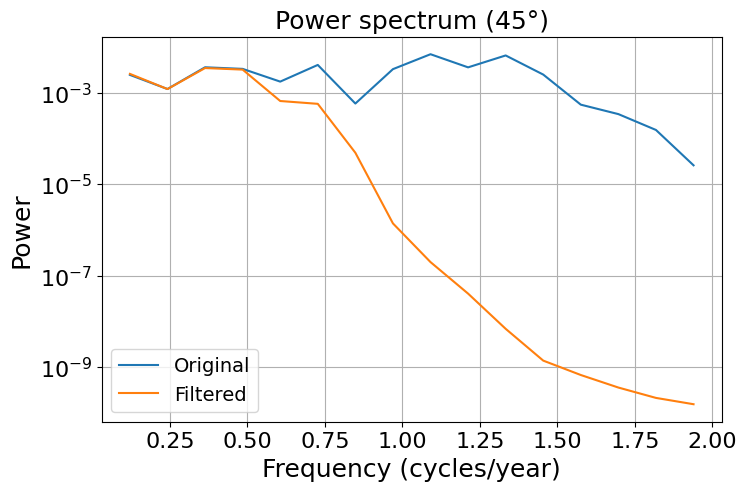

In [ ]:

# choose latitude
lat = 45

x = anom_dt.sel(LATITUDE=lat).values
x_filt = mht_smooth_anom.sel(LATITUDE=lat).values

# remove NaNs
mask = np.isfinite(x) & np.isfinite(x_filt)
x = x[mask]
x_filt = x_filt[mask]

# quarterly sampling
fs = 4  # samples/year

# spectra
f, Pxx = welch(
    x,
    fs=fs,
    window="hann",
    nperseg=len(x)//2,
    detrend="constant"
)

f2, Pxx2 = welch(
    x_filt,
    fs=fs,
    window="hann",
    nperseg=len(x_filt)//2,
    detrend="constant"
)

# remove zero frequency
f = f[1:]
Pxx = Pxx[1:]

f2 = f2[1:]
Pxx2 = Pxx2[1:]

plt.figure(figsize=(8,5))

plt.semilogy(f, Pxx, label="Original")
plt.semilogy(f2, Pxx2, label="Filtered")

plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Power")
plt.title(f"Power spectrum ({lat}°)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
ds_raw = mht_mean
ds_raw_anom = mht_anom
ds = mht_smooth
ds_anom = mht_smooth_anom
ds_anom_prob = mht_smooth_anom_prob


## colors for plotting

In [ ]:
lats
cmap = plt.cm.coolwarm 

colors = [cmap(i / (len(lats) - 1)) for i in range(len(lats))]

label_map = {lat: lat_labels[i] for i, lat in enumerate(lats)}


# for NAN checking

In [ ]:

# da = mht_smooth
# print(da.isnull().sum())
# print(f"NaN percentage: {da.isnull().mean() * 100:.2f}%")

# nan_any  = da.isnull().any(dim='TIME')   # True if ANY sample is NaN
# nan_all  = da.isnull().all(dim='TIME')   # True if ALL samples are NaN

# print("Inconsistent NaNs (some samples missing, not all):", 
#       bool((nan_any & ~nan_all).any()))
# # Visualize gaps

# nan_map = da.isnull()

# nan_map.plot(x='TIME', y='lat', cmap='viridis')
# # plt.xlim(right=pd.Timestamp("2005-01-01"))
# plt.title("NaN fraction across posterior samples")


In [ ]:
mht_anom_lower_ci = ds_anom_prob.quantile(0.05, dim="posterior_samples", skipna=True)   
mht_anom_upper_ci = ds_anom_prob.quantile(0.95, dim="posterior_samples", skipna=True)   


In [ ]:
# ci = False

# # --- Setup ---
# lat_min, lat_max = -38, 63  # slightly beyond data range for padding
# lon_min, lon_max = -80, 20
# fig = plt.figure(figsize=(8, 12))

# map_left   = 0.05
# map_right  = 0.75
# ts_left    = 0.05  # start of time series within the map
# ts_right   = 0.75  # same right edge as map
# fig_bottom = 0.04
# fig_top    = 0.96

# def lat_to_fig_y(lat):
#     return fig_bottom + (lat - lat_min) / (lat_max - lat_min) * (fig_top - fig_bottom)

# # --- Map (same as before) ---
# ax_map = fig.add_axes([map_left, fig_bottom,
#                         map_right - map_left, fig_top - fig_bottom],
#                        projection=ccrs.PlateCarree())
# ax_map.set_aspect('auto')
# ax_map.set_extent([lon_min, lon_max, lat_min, lat_max],
#                    crs=ccrs.PlateCarree())
# ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
# # ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
# # ax_map.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)


# # for lat in lats:
#     # ax_map.plot([lon_min, lon_max], [lat, lat],
#     #             color='darkred', linewidth=0.8,
#     #             alpha=0.3, transform=ccrs.PlateCarree())

# # --- Time series panels ON TOP of map ---
# panel_height = 0.060

# for i, lat in enumerate(lats):
#     fig_y_center = lat_to_fig_y(lat)
#     bottom = np.clip(fig_y_center - panel_height / 2,
#                      fig_bottom, fig_top - panel_height)

#     # place axes overlapping the map
#     ax = fig.add_axes([ts_left, bottom,
#                         ts_right - ts_left, panel_height],
#                        facecolor='none')  # transparent background!
#     ax.xaxis.set_major_locator(mdates.YearLocator(4, month=1, day=1))
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#     anom = ds_anom.isel(lat=i)
    
#     # plot the timeseries 
#     ax.plot(ds_anom.TIME, anom, color="darkred", linewidth=2.0, zorder=5)

#     # # plot the confidence interval
#     if ci:
#         lower = mht_anom_lower_ci.isel(lat=i)
#         upper = mht_anom_upper_ci.isel(lat=i)
    
#         ax.fill_between(
#             anom.TIME.values,
#             lower,
#             upper,
#             color="darkred",
#             alpha=0.4,
#             edgecolor="none",
#             zorder=3,
#         )
#         savename = "MHT_stacked_map_CI"

#     else:
#         savename = "MHT_stacked_map"
#     ax.axhline(0, color='grey', linestyle='--', linewidth=1, zorder=4)
#     ax.set_ylim(-0.4, 0.4)


#     # hide all spines and ticks — let the map show through
#     for spine in ax.spines.values():
#         spine.set_visible(False)
#     ax.set_yticks([-0.4, 0.0, 0.4])
#     ax.set_yticklabels(['-0.4', '0', '0.4'], fontsize=16)
#     ax.tick_params(labelbottom=False, bottom=False)

#     if i % 2 == 0:  # even -> y-axis on left
#         ax.yaxis.set_label_position('left')
#         ax.yaxis.tick_left()
#         for spine in ax.spines.values():
#             spine.set_visible(False)
#         ax.spines['left'].set_visible(True)
#     else:  # odd -> y-axis on right
#         ax.yaxis.set_label_position('right')
#         ax.yaxis.tick_right()
#         for spine in ax.spines.values():
#             spine.set_visible(False)
#         ax.spines['right'].set_visible(True)
    
#     # lat label always on the far right
#     lat_label = f"{abs(lat):.0f}°{'N' if lat >= 0 else 'S'}"
#     ax.text(1.08, 0.5, lat_label, transform=ax.transAxes,
#             va='center', ha='left', fontsize=16)
#     # only show x ticks on bottom panel
#     if i == len(lats) - 1:
#         ax.tick_params(labelbottom=True)
#         ax.xaxis.set_major_locator(mdates.YearLocator(4, month=1, day=1))
#         ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#         # ax.set_xlabel('Year', fontsize=16)
#     else:
#         ax.tick_params(labelbottom=False)
#         ax.xaxis.set_major_locator(mdates.YearLocator(4, month=1, day=1))
# # y label and title
# # fig.text(ts_left - 0.02, (fig_top + fig_bottom) / 2,
# #          'MHT anom. (PW)', va='center',
# #          rotation='vertical', fontsize=9)

# fig.suptitle('4-quarter low-pass filtered MHT anomalies (PW)',
#              fontsize=20, y=1)

# plt.savefig(f'figures/timeseries/{savename}.png', dpi=300, bbox_inches='tight')
# plt.show()

In [ ]:

# cmap = plt.cm.RdBu_r
# cmap = cmo.cm.curl

# cmap = mcolors.ListedColormap(cb.diverging.BrBG_20.mpl_colors)
# colors = cmap(np.linspace(0, 1, 20))
# sliced_cmap = mcolors.ListedColormap(colors)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.diverging.RdBu_11_r.mpl_colors
)

colors = cmap(np.linspace(0, 1, 40))
sliced_cmap_corr = mcolors.ListedColormap(colors)



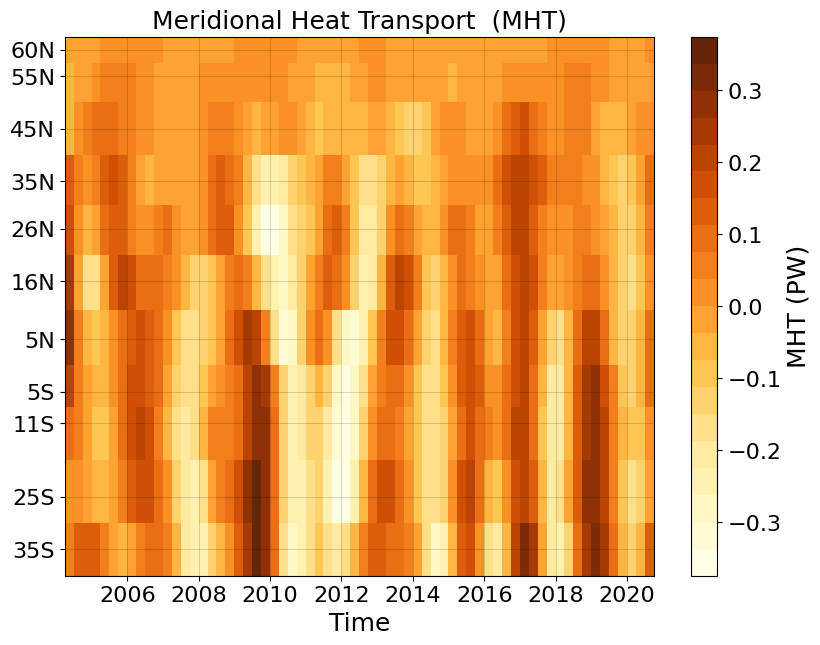

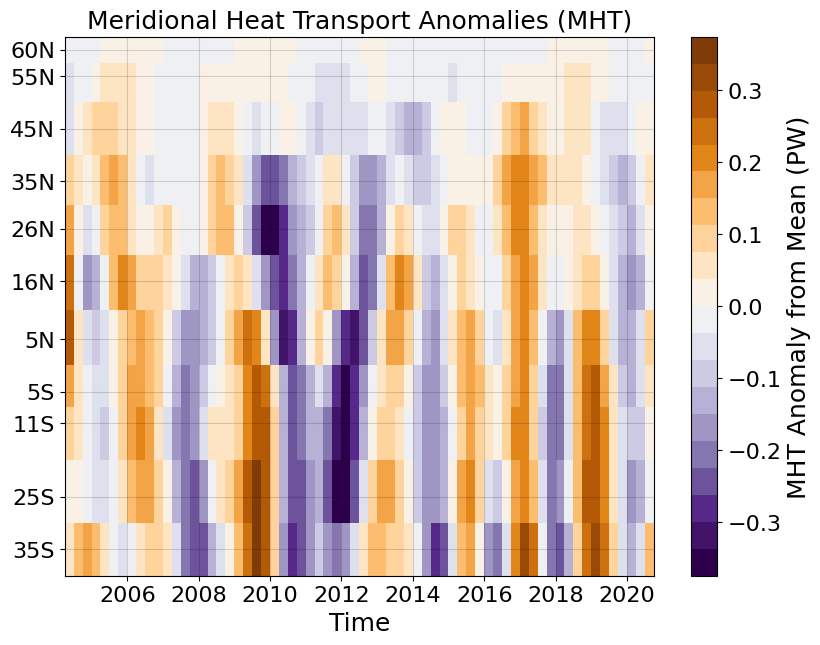

In [ ]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.sequential.YlOrBr_9.mpl_colors
)

colors = cmap(np.linspace(0, 1, 20))
sliced_cmap_mht = mcolors.ListedColormap(colors)


plot_hovmöller(ds, lats, cmap=sliced_cmap_mht, savefig=True, anomalies=False)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.diverging.PuOr_11_r.mpl_colors
)

colors = cmap(np.linspace(0, 1, 20))
sliced_cmap_anom = mcolors.ListedColormap(colors)


plot_hovmöller(ds_anom, lats, cmap=sliced_cmap_anom, savefig=True, anomalies=True)

In [ ]:
# array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])




In [ ]:
# corr_matrix = np.full((len(lats), len(all_lags)), np.nan)


# fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
# axes = axes.flatten() 
# for ax, ref_lat in zip(axes, ref_lats):
#     ref_idx = np.argmin(np.abs(lats - ref_lat))
#     ts_ref  = MHT_mean.isel(lat=ref_idx).values

#     corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
#     for i, lat in enumerate(lats):
#         ts = MHT_mean.isel(lat=i).values
#         pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
#         neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
#         full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
#         corr_matrix[i, :] = full_corr


#     peak_lags = np.argmax(corr_matrix, axis=1)           # index of max correlation
#     peak_lags = all_lags[peak_lags]                       # convert to actual lag values
#     peak_corr = np.max(corr_matrix, axis=1)               # correlation at peak lag

#     # plot propagation speed
#     ax.plot(peak_lags, lats, marker="o")
    
#     ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N')
  
#     ax.set_yticks(ytick_pos)
#     ax.set_yticklabels(ytick_labels, fontsize=11)
#     ax.set_xticks(np.arange(all_lags[1], all_lags[-1] + 1, 2))

    

## statisics - significance testing!

66

In [ ]:
N = len(mht_mean.TIME.values)
all_lags = np.linspace(-12, 13,)

time_unit = "years"  # or "months"
if time_unit == "months":
    del_t = 3
if time_unit == "years":
    del_t = 0.25
    
# r_crits = {}
n_effs = {}

plateau_lats = [45, 35]  

for idx, lat in enumerate(lats): 
    print(f"Latitude: {lat:.1f}°")
    # mht_lat = ds.isel(lat=idx)
    mht_lat = ds_anom.isel(lat=idx)
    
    # mht_lat_std = mht_lat.std(dim='posterior_samples')
    # if lat in plateau_lats:
    #      method = "plateau"
    # else: 
    #     method = "0cross"
    method = "0cross"
    its, max_lags = integral_time_scale(mht_lat, del_t=del_t, method=method)
    
    N_eff = N*del_t/its
    
    n_effs[lat] = N_eff
     
    
    print(f" ITS: {its:.2f} {time_unit}, N_eff: {N_eff:.1f} samples")
    acf_vals, _, _ = acf_calc_plot(mht_lat, N_eff=12, plot=False, title=f"Autocorrelation Function at {lat:.1f}°N")
    



Latitude: 60.0°
 ITS: 1.59 years, N_eff: 10.4 samples
Latitude: 55.0°
 ITS: 1.59 years, N_eff: 10.4 samples
Latitude: 45.0°
 ITS: 3.14 years, N_eff: 5.3 samples
Latitude: 35.0°
 ITS: 2.53 years, N_eff: 6.5 samples
Latitude: 26.0°
 ITS: 1.19 years, N_eff: 13.9 samples
Latitude: 16.0°
 ITS: 0.79 years, N_eff: 21.0 samples
Latitude: 5.0°
 ITS: 0.78 years, N_eff: 21.2 samples
Latitude: -5.0°
 ITS: 0.83 years, N_eff: 20.0 samples
Latitude: -11.0°
 ITS: 0.84 years, N_eff: 19.6 samples
Latitude: -25.0°
 ITS: 0.83 years, N_eff: 19.8 samples
Latitude: -35.0°
 ITS: 0.79 years, N_eff: 21.0 samples


In [ ]:
ds_anom

NameError: name 'ds_anom' is not defined

/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_3889/1605508286.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


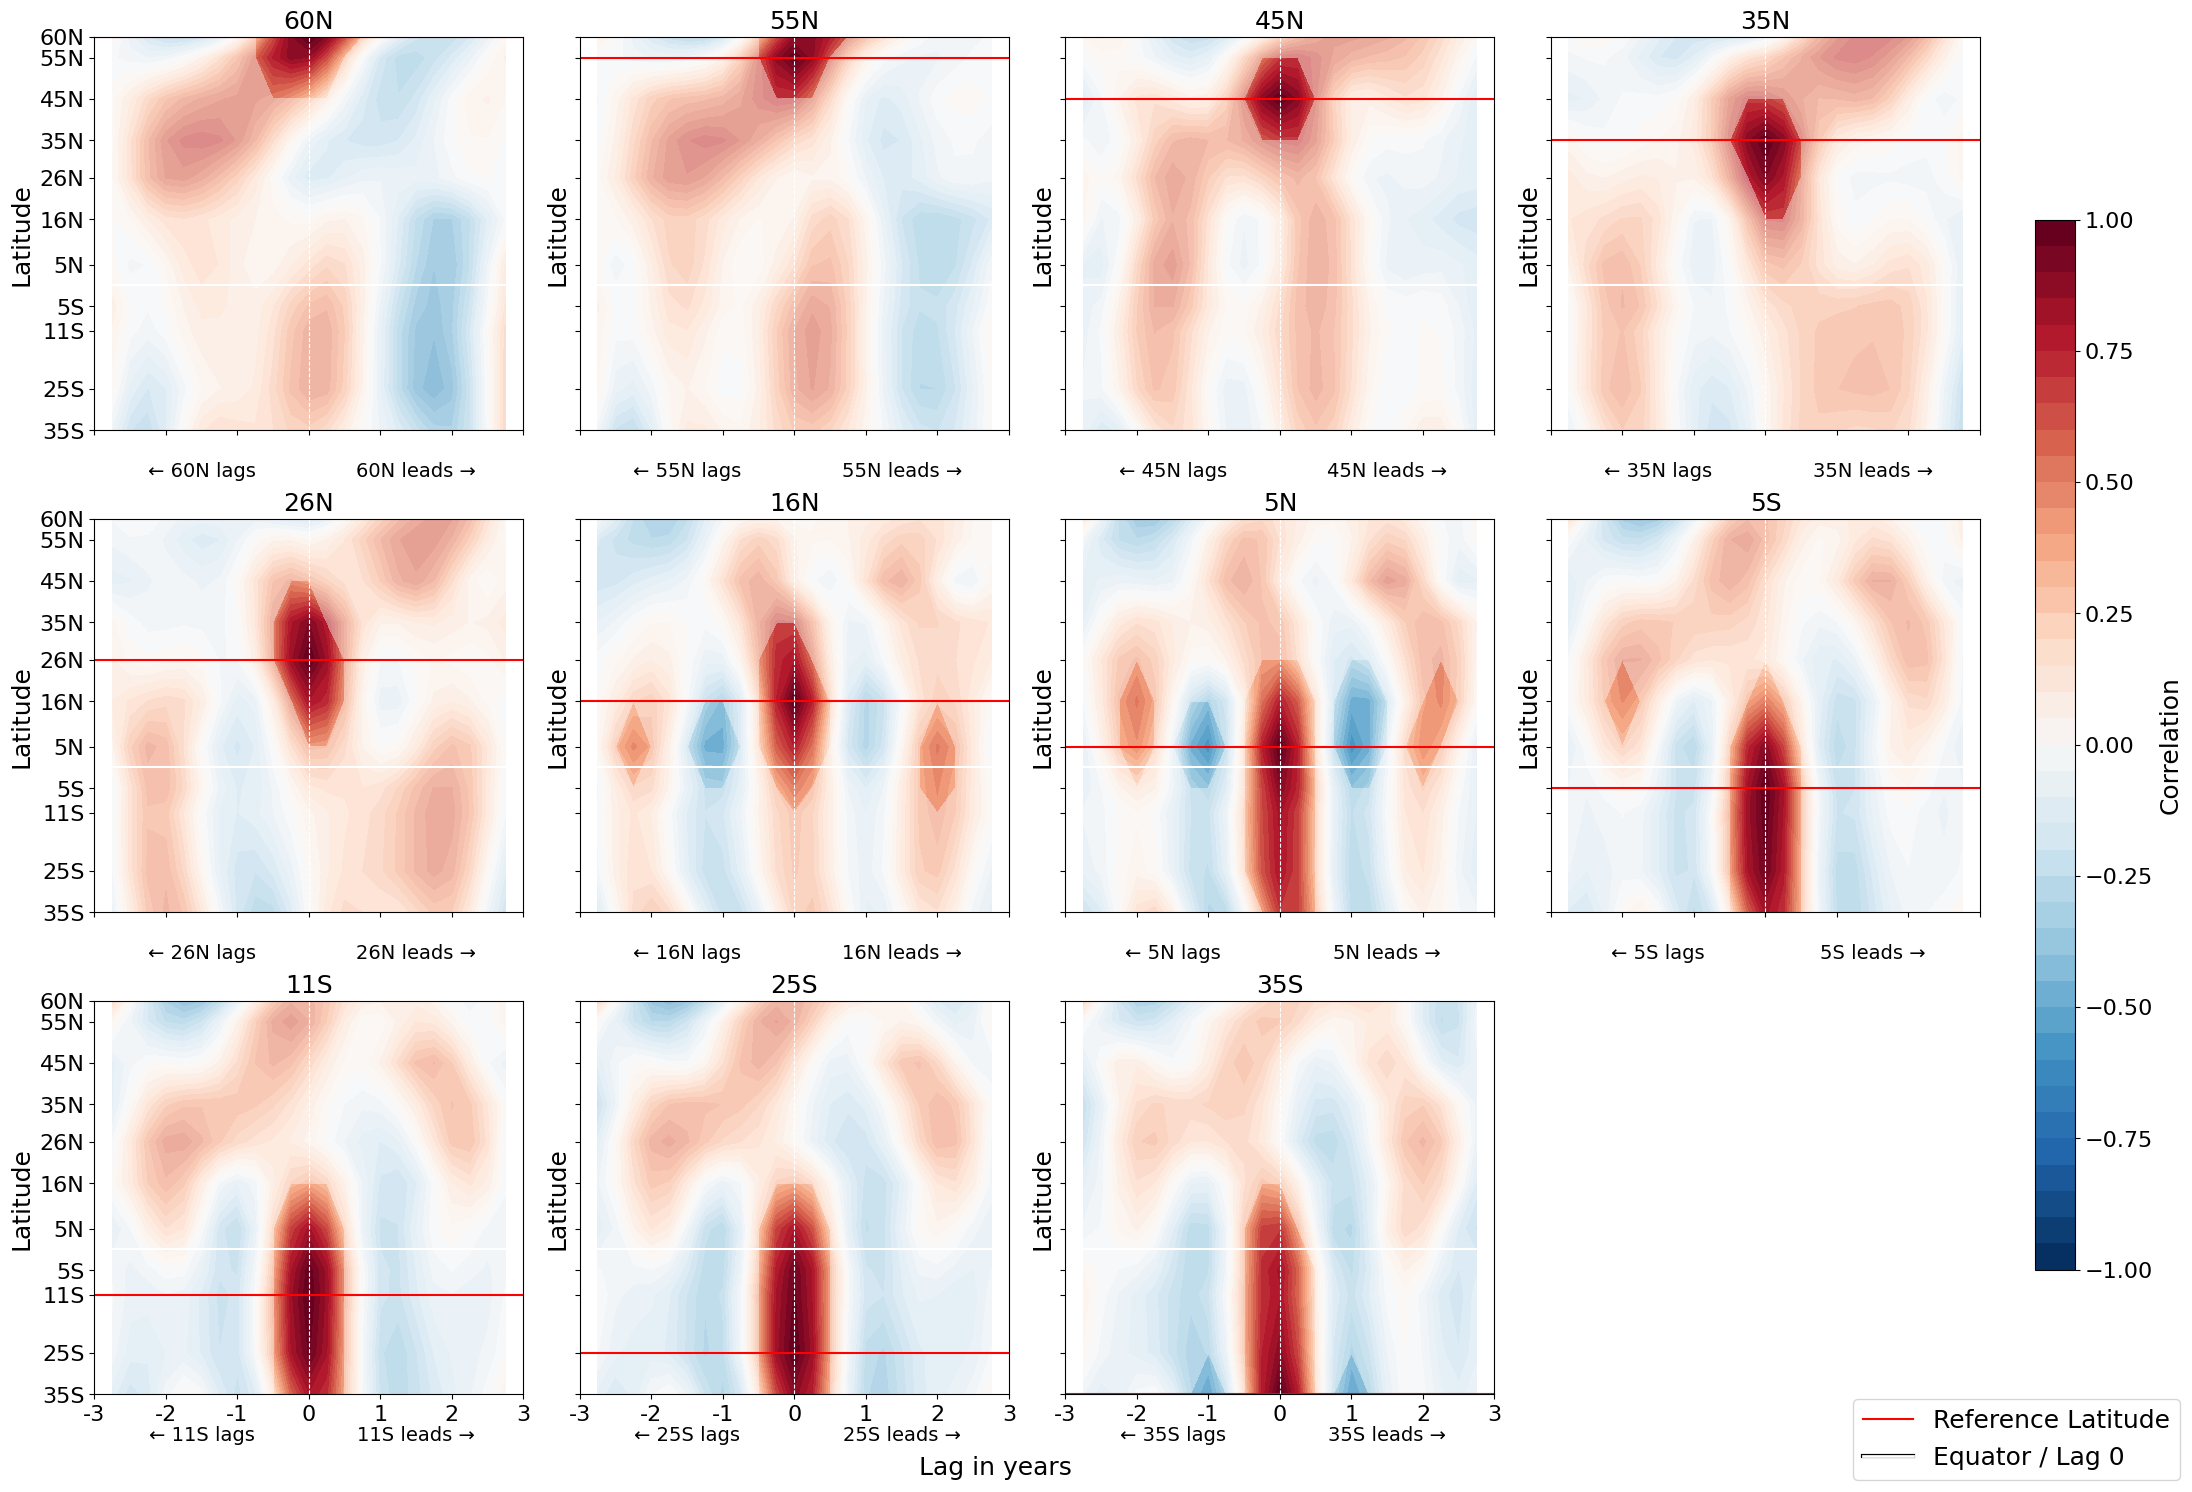

In [ ]:
significance = True 
cmap = sliced_cmap_corr
# cmap = cmo.cm.curl

corr_matrix = np.full((len(lats), len(all_lags)), np.nan)

ref_lats = lats

ytick_pos    = [-35, -25, -11, -5,  5,  16, 26, 35, 45, 55, 60]
ytick_labels = ["35S","25S","11S","5S","5N","16N","26N","35N","45N","55N","60N"]

lag_units = "months" if time_unit == "months" else "years"

   
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharey=True, sharex=True)
axes = axes.flatten() 



for ax, ref_lat in zip(axes, ref_lats):
    ref_idx = np.argmin(np.abs(lats - ref_lat))
    ts_ref  = ds_anom.isel(lat=ref_idx).values

    corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
    significance_mask = np.zeros((len(lats), len(all_lags)), dtype=bool)
    
    n_eff_ref = n_effs[ref_lat]
    
    ref_i = np.argmin(np.abs(lats - ref_lat))
    
    for i, lat in enumerate(lats):
        ts = ds_anom.isel(lat=i).values
        pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
        neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
        full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
        corr_matrix[i, :] = full_corr
        
        n_eff_lat = n_effs[lat]
        min_n_eff = min(n_eff_ref, n_eff_lat)
        r_crit = critical_r(min_n_eff)  # critical r for
        # print(f"Ref lat: {ref_lat:.1f}°, Lat: {lat:.1f}°, N_eff_ref: {n_eff_ref:.1f}, N_eff_lat: {n_eff_lat:.1f}, r_crit: {r_crit:.3f}")
        significance_mask[i, :] = np.abs(full_corr) >= r_crit 
        # shape of significance_mask is (n_lats, n_lags*2-1)
        
    # --- Plot ---
    cf = ax.contourf(
        -all_lags, lats, corr_matrix,
        levels=np.linspace(-1, 1, 41),
        cmap=cmap,
    )
    if significance:
        ax.contourf(-all_lags, lats,
                    np.where(~significance_mask, 1, np.nan),
                    levels=[0.5, 1.5],
                    colors='white', alpha=0.4)
        savename = "lag_corr_significance.png"
    else:
        savename = f'lag_corr.png'

    ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N')
    
    # ax.axhline(35, color='purple', linewidth=1.5, linestyle='-')
    # ax.axhline(16, color='purple', linewidth=1.5, linestyle='-')
    # ax.axhline(5, color='green', linewidth=1.5, linestyle='-')
    # ax.axhline(-34, color='green', linewidth=1.5, linestyle='-')
    
    ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
    ax.axhline(0, color='white', linewidth=1.5)

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_labels)
    if lag_units == "months":
        xticks = np.arange(all_lags[0], all_lags[-1] + 1, 2)
    elif lag_units == "years":
        lag_step = 4
        xticks = np.arange(-nlags, nlags + 1, lag_step)

    ax.set_xticks(xticks)
    if lag_units == "years":
        xticklabels = (xticks // lag_step).astype(str)
    else:
        xticklabels = xticks.astype(str)

    # replace the 0 label, keep others, or just leave numbers and add text annotations
    ax.set_xticklabels(xticklabels)
    ref_label = f"{abs(ref_lat):.0f}{'N' if ref_lat >= 0 else 'S'}"


    # Add directional annotations below the axis
    ax.annotate(f'← {ref_label} lags', xy=(0.25, -0.08), xycoords='axes fraction',
                ha='center', va='top', fontsize=14)
    ax.annotate(f'{ref_label} leads →', xy=(0.75, -0.08), xycoords='axes fraction',
                ha='center', va='top', fontsize=14)

    # ax.set_xlabel(f'Lag')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{ref_label}')

cbar_ax = fig.add_axes([1.02, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cf, cax=cbar_ax, label='Correlation')

## add handles
ref_lat = mlines.Line2D([], [], color='red', linewidth=1.5, label=f'Reference Latitude')
eq = mlines.Line2D([], [], color='white', linewidth=2, linestyle='-',
        path_effects=[pe.withStroke(linewidth=3, foreground='black')],
        label="Equator / Lag 0"
)
# band2 = mlines.Line2D([], [], color='green', linewidth=1.5, linestyle='-', label="Coherence Band 2")

fig.legend(handles=[ref_lat,
                    eq, 
                    # band2
                    ], 
           loc='lower right', fontsize=18) #, bbox_to_anchor=(1.05, 1))

fig.supxlabel('Lag in years', fontsize=18)

axes[-1].set_visible(False)

plt.tight_layout()
os.makedirs("figures/lead_lag", exist_ok=True)
plt.savefig(f'figures/lead_lag/{savename}', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_3889/326855533.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


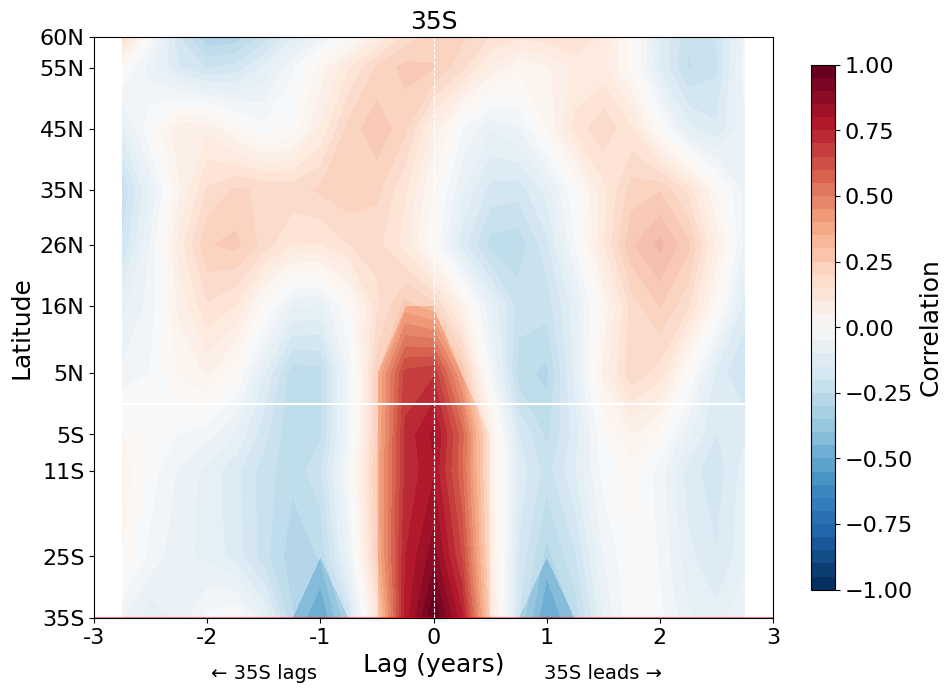

In [ ]:
  
fig, ax = plt.subplots(figsize=(8, 7))

cmap = sliced_cmap_corr

ref_lat = -35


ref_idx = np.argmin(np.abs(lats - ref_lat))
ts_ref  = ds_anom.isel(lat=ref_idx).values

corr_matrix_ccf = np.full((len(lats), len(all_lags)), np.nan)
significance_mask = np.zeros((len(lats), len(all_lags)), dtype=bool)

n_eff_ref = n_effs[ref_lat]

ref_i = np.argmin(np.abs(lats - ref_lat))

for i, lat in enumerate(lats):
    # print(i, lat)
    ts = ds_anom.isel(lat=i).values
    # print(MHT_mean.isel(lat=i).LATITUDE.values)
    # ccf does: correlating the reference series at time t with the other latitude series τ years later
    
    
    pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
    neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
    

    full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
    corr_matrix_ccf[i, :] = full_corr
    
    n_eff_lat = n_effs[lat]
    min_n_eff = min(n_eff_ref, n_eff_lat)
    r_crit = critical_r(min_n_eff)  # critical r for
    # print(f"Ref lat: {ref_lat:.1f}°, Lat: {lat:.1f}°, N_eff_ref: {n_eff_ref:.1f}, N_eff_lat: {n_eff_lat:.1f}, r_crit: {r_crit:.3f}")
    significance_mask[i, :] = np.abs(full_corr) >= r_crit 
    # shape of significance_mask is (n_lats, n_lags*2-1)
    
# --- Plot ---
cf = ax.contourf(
    -all_lags, lats, corr_matrix_ccf,
    levels=np.linspace(-1, 1, 41),
    cmap=cmap,
)
if significance:
    ax.contourf(-all_lags, lats,
                np.where(~significance_mask, 1, np.nan),
                levels=[0.5, 1.5],
                colors='white', alpha=0.4)
    savename = f"lag_corr_significance_{ref_lat}.png"
else:
    savename = f"lag_corr_{ref_lat}.png"

ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N', alpha=0.5)

# ax.axhline(35, color='purple', linewidth=1.5, linestyle='-')
# ax.axhline(16, color='purple', linewidth=1.5, linestyle='-')
# ax.axhline(5, color='green', linewidth=1.5, linestyle='-')
# ax.axhline(-34, color='green', linewidth=1.5, linestyle='-')

ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.axhline(0, color='white', linewidth=1.5)

ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_labels)
if lag_units == "months":
    xticks = np.arange(all_lags[0], all_lags[-1] + 1, 2)
elif lag_units == "years":
    lag_step = 4
    xticks = np.arange(-nlags, nlags + 1, lag_step)

ax.set_xticks(xticks)
if lag_units == "years":
    xticklabels = (xticks // lag_step).astype(str)
# else:
#     xticklabels = xticks.astype(str)

# replace the 0 label, keep others, or just leave numbers and add text annotations
# ax.set_xticklabels([str(abs(int(t))) for t in xticklabels])
ax.set_xticklabels(xticklabels)

ax.set_xlabel(f'Lag (years)')

ref_label = f"{abs(ref_lat):.0f}{'N' if ref_lat >= 0 else 'S'}"

# Add directional annotations below the axis
ax.annotate(f'← {ref_label} lags', xy=(0.25, -0.08), xycoords='axes fraction',
             ha='center', va='top', fontsize=14)
ax.annotate(f'{ref_label} leads →', xy=(0.75, -0.08), xycoords='axes fraction',
             ha='center', va='top', fontsize=14)

        
# ax.set_xlabel(f'Lag')

ax.set_ylabel('Latitude')
ax.set_title(f'{ref_label}')

cbar_ax = fig.add_axes([1.02, 0.15, 0.03, 0.75])  # [left, bottom, width, height]
fig.colorbar(cf, cax=cbar_ax, label='Correlation')

## add handles
ref_lat = mlines.Line2D([], [], color='red', linewidth=1.5, label=f'Reference Latitude')
# band1 = mlines.Line2D([], [], color='purple', linewidth=1.5, linestyle='-', label="Coherence Band 1")
# band2 = mlines.Line2D([], [], color='green', linewidth=1.5, linestyle='-', label="Coherence Band 2")

# fig.legend(handles=[ref_lat,
#                     # band1, 
#                     # band2
#                     ], 
#            loc='lower right', fontsize=18) #, bbox_to_anchor=(1.05, 1))

axes[-1].set_visible(False)
plt.tight_layout()
os.makedirs("figures/lead_lag", exist_ok=True)
plt.savefig(f'figures/lead_lag/{savename}', dpi=300, bbox_inches='tight')
plt.show()

## calc by hand the correlation to check if what ccf does checks out
- did check out!! :) 
also calculateed difference between correlation matrices

In [ ]:
# ref_lat = 60
# ref_idx = np.argmin(np.abs(lats - ref_lat))


# ts_ref  = ds_anom.isel(lat=ref_idx)

# corr_matrix_corrcoef = np.full((len(lats), len(all_lags)), np.nan)

# for i, lat in enumerate(lats):
#     ts = ds_anom.isel(lat=i)
    
#     for j, timedelta in enumerate(all_lags):
#         ts_shifted = ts.shift(TIME=timedelta)
#         # print(ts_shifted)
#         ts_ref_a, ts_shifted_a = xr.align(ts_ref, ts_shifted, join="inner")
#         mask = np.isfinite(ts_ref_a) & np.isfinite(ts_shifted_a)
#         corr = np.corrcoef(
#             ts_ref_a.values[mask],
#             ts_shifted_a.values[mask]
#         )[0, 1]
#         corr_matrix_corrcoef[i, j] = corr
        
#         # print(f"{ref_lat} and {lat} correlation for timeshift {timedelta}: ", corr)

# lag_vals = np.array(all_lags)  # e.g. array of integers from -3 to 3

# # cf = ax.contourf(
# #     lag_vals, lats, corr_matrix_corrcoeff,
# #     levels=np.linspace(-1, 1, 21),
# #     cmap="RdBu_r",
# #     vmin=-1, vmax=1,
# #     extend="both"
# # )

# # # reference lines
# # ax.axvline(0, color="white", linestyle="--", linewidth=1)
# # ax.axhline(ref_lat, color="white", linewidth=1)

# # ax.set_xlabel("Lag")
# # ax.set_ylabel("Latitude")
# # ax.set_title(f"{ref_lat}N")

# # cbar = fig.colorbar(cf, ax=ax, label="Correlation")

# # plt.tight_layout()
# # plt.show()

# diff_matrix = corr_matrix_corrcoef - corr_matrix_ccf

# fig, ax = plt.subplots(figsize=(8, 7))

# cf = ax.contourf(
#     all_lags, lats, diff_matrix,
#     levels=np.linspace(-0.2, 0.2, 41),
#     cmap="RdBu_r",
#     extend="both"
# )

# ax.axhline(ref_lat, color='red', linewidth=1.5, alpha=0.5)
# ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
# ax.axhline(0, color='white', linewidth=1.5)

# ax.set_yticks(ytick_pos)
# ax.set_yticklabels(ytick_labels)
# ax.set_xlabel('Lag')
# ax.set_ylabel('Latitude')
# ax.set_title(f'corrcoef - ccf ({ref_label})')

# fig.colorbar(cf, ax=ax, label='Correlation difference')
# plt.tight_layout()
# plt.show()

In [ ]:
rcrit_matrix = np.zeros((len(lats), len(lats)))
neff_matrix  = np.zeros((len(lats), len(lats)))

for ref_i, ref_lat in enumerate(lats):        # ref_i is just the enumerate index
    n_eff_ref = n_effs[ref_lat]
    for i, lat in enumerate(lats):
        n_eff_lat = n_effs[lat]
        min_n_eff = min(n_eff_ref, n_eff_lat)
        rcrit_matrix[ref_i, i] = critical_r(min_n_eff)
        neff_matrix[ref_i, i]  = min_n_eff


# inverse to have South to north not the otherway around
rcrit_plot = rcrit_matrix[::-1, ::-1]
neff_plot  = neff_matrix[::-1,  ::-1]
labels_sn  = ytick_labels  # already south to north: 35S...60N

In [ ]:
for i, label in enumerate(lat_labels):
    # print(label)
    label = label.replace(".0", "")
    lat_labels[i] = label
# lat_labels = [str(int(i:.1f))]

In [ ]:
#ds_anom.TIME
# 02 05 08 11 

In [ ]:
ref_lat = 5

ref_idx = np.argmin(np.abs(lats - ref_lat))
ts_ref  = ds_anom.isel(lat=ref_idx)
ts_ref_kelly = ts_ref.sel(TIME=slice(None, "2011-01-01"))
ts_ref_after_kelly = ts_ref.sel(TIME=slice("2011-01-01", None))

mht_smooth_anom_kelly = mht_smooth_anom.sel(TIME=slice(None, "2011-01-01"))
mht_smooth_anom_after_kelly = mht_smooth_anom.sel(TIME=slice("2011-01-01", None))
# before and after 2009
# before and after 2011 -- Kelly
ds_anom_b2011 = ds_anom.sel(TIME=slice(None, "2011-01-01"))
ds_anom_a2011 = ds_anom.sel(TIME=slice("2011-01-01", None))
# before and after 2014
ds_anom_b2014 = ds_anom.sel(TIME=slice(None, "2014-01-01"))
ds_anom_a2014 = ds_anom.sel(TIME=slice("2014-01-01", None))

In [ ]:
# year_sel = 2009
# month = "05"
# ds_anom_b2008 = ds_anom.sel(TIME=slice(None, f"{year_sel}-{month}-01"))
# # ds_anom_a2008 = ds_anom.sel(TIME=slice(f"{year_sel}-{month}-01", None))
# plot_crosscorr(ds_anom_b2008, lats, lat_labels, significance=True, n_effs=n_effs, title=f"Before {year_sel}, {month}", cmap=sliced_cmap_corr, savefig=True, savename="crosscorr_b2008.png")
# # plot_crosscorr(ds_anom_a2008, lats, lat_labels, significance=True, n_effs=n_effs, title="After 2008", cmap=sliced_cmap_corr, savefig=True, savename="crosscorr_a2008.png")
# # plot_crosscorr(ds_anom.sel(TIME=slice("2008-01-01", "2014-01-01")), lats, lat_labels, significance=True, n_effs=n_effs, title="2008- 2014",cmap=sliced_cmap_corr, savefig=False)


In [ ]:


dates = []
for year in range(2008, 2020):
    for month in ["02", "05", "08", "11"]:
        dates.append(f"{year}-{month}-01")

min_samples = 8  # skip frames where prior/later would be too small to be meaningful
frames = []

for date in dates:
    ds_prior = ds_anom.sel(TIME=slice(None, date))
    ds_later = ds_anom.sel(TIME=slice(date, None))

    if ds_prior.sizes["TIME"] < min_samples or ds_later.sizes["TIME"] < min_samples:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    plot_crosscorr_gif(ds_prior, lats, lat_labels, significance=True, n_effs=n_effs,
                   title=f"Prior to {date} (n={ds_prior.sizes['TIME']})",
                   cmap=sliced_cmap_corr, ax=axes[0])
    plot_crosscorr_gif(ds_later, lats, lat_labels, significance=True, n_effs=n_effs,
                   title=f"After {date} (n={ds_later.sizes['TIME']})",
                   cmap=sliced_cmap_corr, ax=axes[1])

    fig.suptitle(date)
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)

frames[0].save(
    "figures/cross_corr/gif/crosscorr_evolution.gif",
    save_all=True,
    append_images=frames[1:],
    duration=500,
    loop=0
)

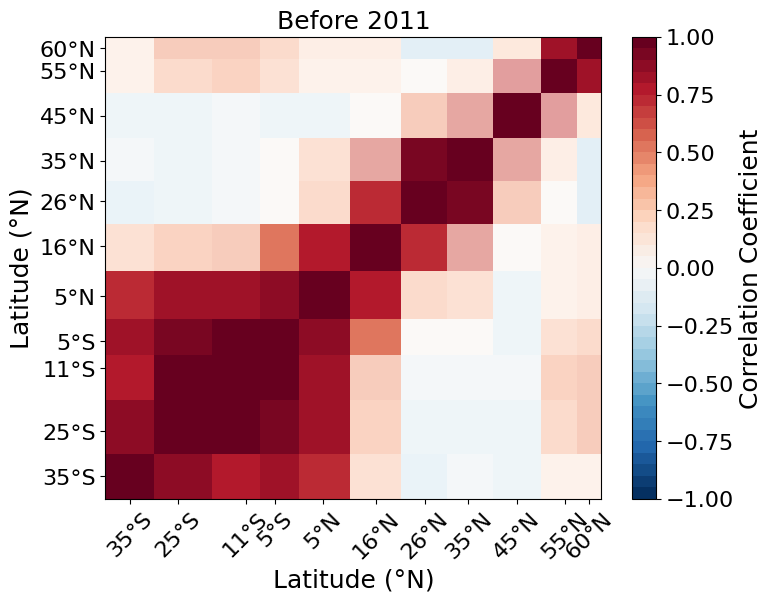

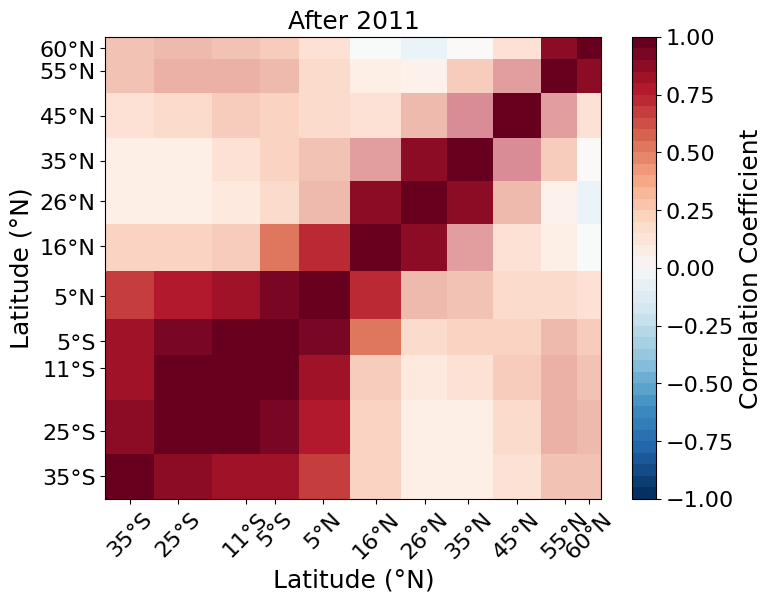

In [ ]:
# plot_crosscorr(ds_anom_b2011, lats, lat_labels, significance=True, n_effs=n_effs, title="Before 2011", cmap=sliced_cmap_corr, savefig=False)
# plot_crosscorr(ds_anom_a2011, lats, lat_labels, significance=True, n_effs=n_effs, title="After 2011", cmap=sliced_cmap_corr, savefig=False)


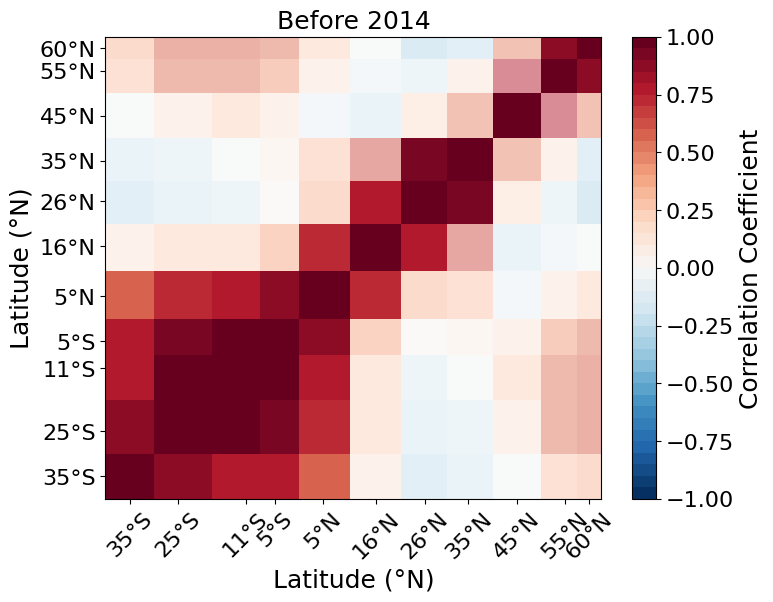

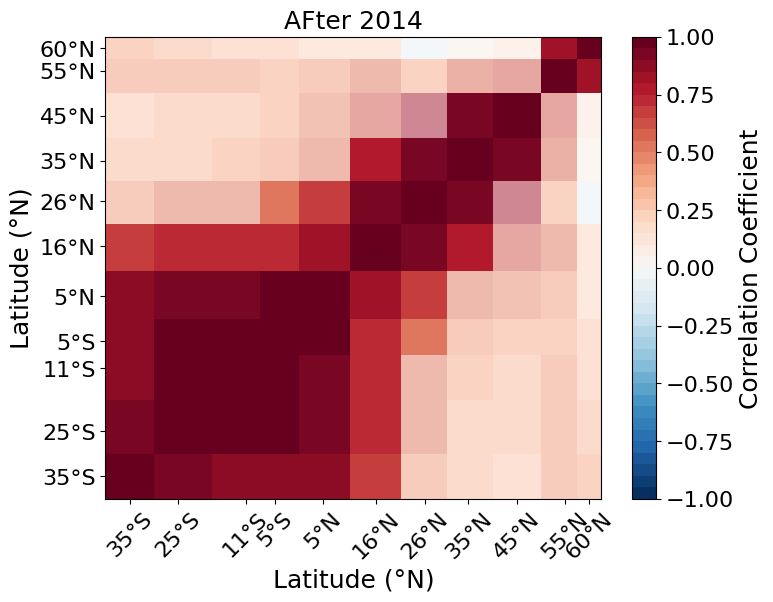

In [ ]:
plot_crosscorr(ds_anom_b2014, lats, lat_labels, significance=True, n_effs=n_effs, title="Before 2014",cmap=sliced_cmap_corr, savefig=False)
plot_crosscorr(ds_anom_a2014, lats, lat_labels, significance=True, n_effs=n_effs, title="AFter 2014", cmap=sliced_cmap_corr, savefig=False)

# zero_lag_corr(ts_ref_kelly, mht_smooth_anom_kelly, lats, lat_labels=lat_labels, plot=True, polar_band=False, savefig=True )
# zero_lag_corr(ts_ref_after_kelly, mht_smooth_anom_after_kelly, lats, lat_labels=lat_labels, plot=True, polar_band=False, savefig=False )

In [ ]:
# fig2, (ax_n, ax_r) = plt.subplots(1, 2, figsize=(14, 7))

# lat_ticks = range(len(lats))


# cf_r = ax_r.contourf(lat_ticks, lat_ticks, rcrit_plot, levels=np.linspace(0, 1, 21), cmap='Reds') #, vmin=0, vmax=1)
# cf_n = ax_n.contourf(lat_ticks, lat_ticks, neff_plot,  levels=20, cmap='Blues')
# plt.colorbar(cf_r, ax=ax_r, label='$r_{crit}$')
# plt.colorbar(cf_n, ax=ax_n, label='$N_{eff}$')

# for ax in [ax_r, ax_n]:
#     ax.set_xticks(lat_ticks)
#     ax.set_xticklabels(labels_sn, rotation=45)
#     ax.set_yticks(lat_ticks)
#     ax.set_yticklabels(labels_sn)
#     ax.set_xlabel('Latitude')
#     ax.set_ylabel('Latitude')
    
#     # equator_idx = len(lats) - 1 - np.argmin(np.abs(lats - 0))
#     # ax.axhline(equator_idx, color='white', linewidth=1.5)
#     # ax.axvline(equator_idx, color='white', linewidth=1.5)

    
# ax_r.set_title('Critical r')
# ax_n.set_title('Effective sample size')

# plt.tight_layout()
# plt.suptitle('Significance parameters per latitude pair', y=1.02)
# # plt.savefig('figures/lead_lag/significance_params.png', dpi=300, bbox_inches='tight')
# plt.show()

In [ ]:
# plot_crosscorr(ds, lats, lat_labels, cmap=sliced_cmap_corr, significance=True, n_effs=n_effs, savefig=False)

## plot timeseries to see if we find the lead lag relationship in the raw data

In [ ]:
lats
cmap = plt.cm.coolwarm 

colors = [cmap(i / (len(lats) - 1)) for i in range(len(lats))]

label_map = {lat: lat_labels[i] for i, lat in enumerate(lats)}


In [ ]:

# reflat1 = 60
# reflat2 = 45

# timedelta = 2
# ref_ds, shifted_ds, lags, stds = lagged_std(ds_anom, ref_lat1=reflat1, ref_lat2=reflat2, timedelta=timedelta, max_lag=50, normalize=True)

# x = ref_ds
# y = shifted_ds
# # Find optimal lag (minimum std)
# opt_lag = lags[np.argmin(stds)]
# print(f"Estimated lag (min std): {opt_lag}")

# # Plot
# fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# axes[0].plot(ds_anom.TIME.values, x, label='x (reference)')
# axes[0].plot(ds_anom.TIME.values, y, label='y (shifted)', alpha=0.7)
# axes[0].set_title('Time Series')
# axes[0].legend()
# axes[0].set_xlabel('Time')

# axes[1].plot(lags, stds, color='steelblue')
# axes[1].axvline(opt_lag, color='red', linestyle='--', label=f'Min std at lag={opt_lag}')
# # axes[1].axvline(true_lag, color='green', linestyle=':', label=f'True lag={true_lag}')
# axes[1].set_title('Std of (x − y_shifted) vs Lag')
# axes[1].set_xlabel('Lag (samples)')
# axes[1].set_ylabel('Std')
# axes[1].legend()

# plt.tight_layout()
# plt.show()


=== 45°N vs 26°N ===
  Best by corr: shift=6, corr=0.536, rmsd=0.10 (in percent:35.584 % ), std=0.105
  Best by RMSD:  shift=6.00, rmsd at this shift, )
  Best combo:   shift=6, corr=0.536, std=0.105rmsd=0.100  (in percent:35.584 % ), score=1.000
vmin and vmax for the reference lat 45 here:  -0.13, 0.15
vmin and vmax for the other lat 26 here:  -0.34, 0.21

=== 45°N vs 16°N ===
  Best by corr: shift=6, corr=0.502, rmsd=0.10 (in percent:36.509 % ), std=0.108
  Best by RMSD:  shift=6.00, rmsd at this shift, )
  Best combo:   shift=6, corr=0.502, std=0.108rmsd=0.103  (in percent:36.509 % ), score=1.000
vmin and vmax for the reference lat 45 here:  -0.13, 0.15
vmin and vmax for the other lat 16 here:  -0.27, 0.23

=== 45°N vs -5°N ===
  Best by corr: shift=6, corr=0.502, rmsd=0.13 (in percent:44.848 % ), std=0.133
  Best by RMSD:  shift=6.00, rmsd at this shift, )
  Best combo:   shift=6, corr=0.502, std=0.133rmsd=0.126  (in percent:44.848 % ), score=1.000
vmin and vmax for the reference 

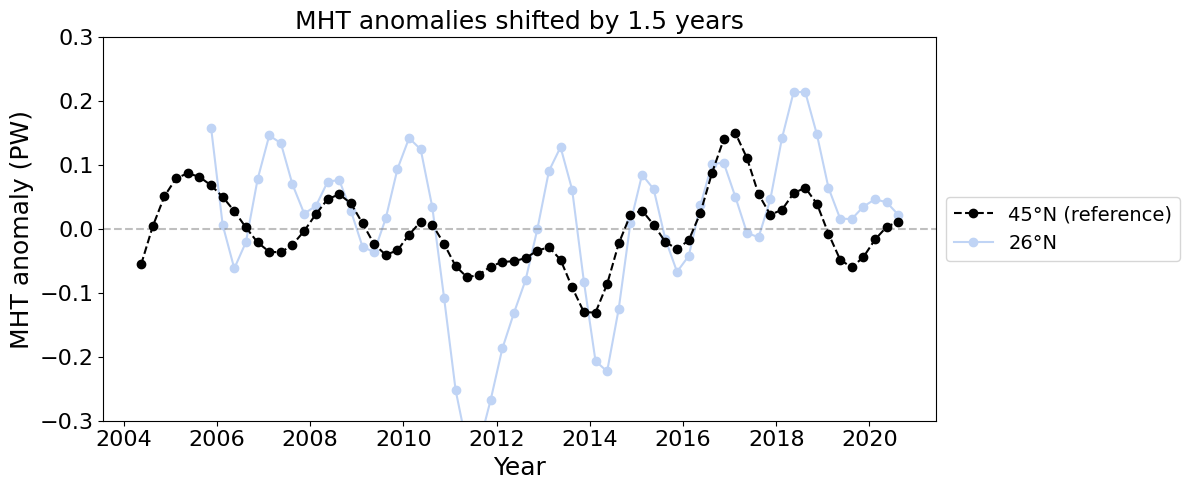


Plotting 16°N with best shift = 6 (1.50 yrs)
Correlation between 45°N and 16°N with a shift of 1.5 years: 0.50


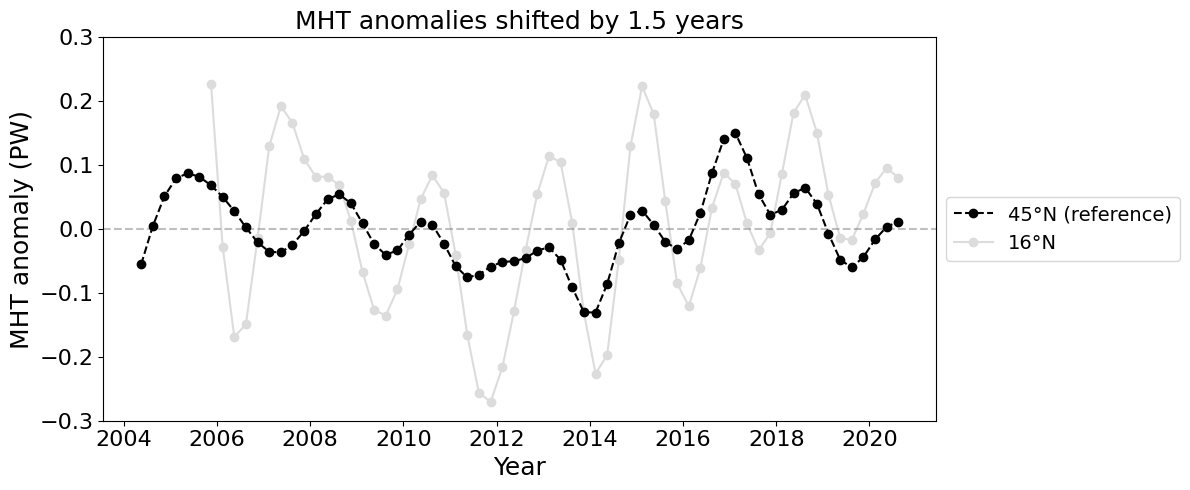


Plotting -5°N with best shift = 6 (1.50 yrs)
Correlation between 45°N and 5°S with a shift of 1.5 years: 0.50


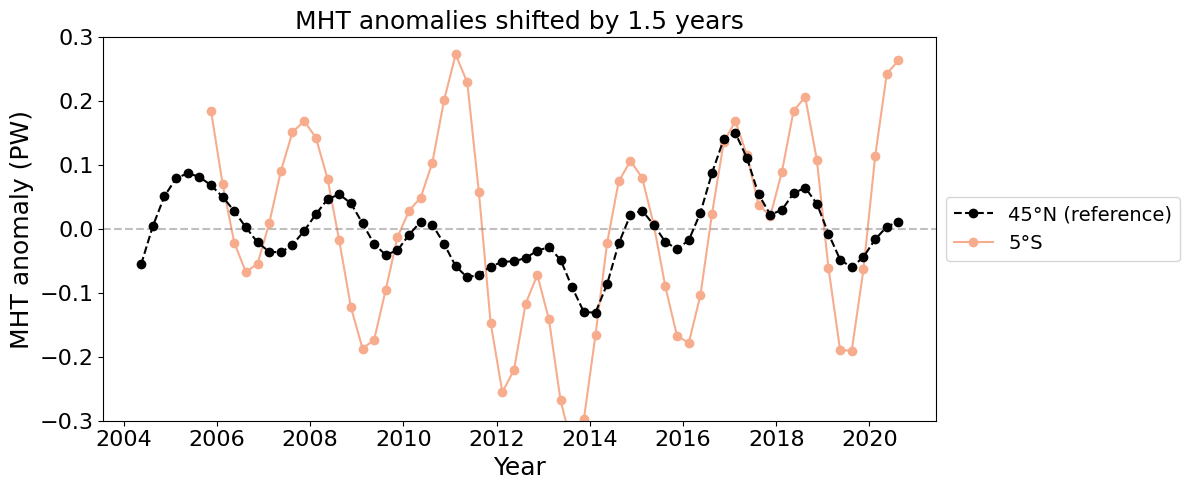

In [ ]:


def find_best_shift(ds, ref_lat, lats_to_check, lags, printout=False,  w_corr=0.5, w_rmsd=0.5):
    
    best_shifts = {}  # store best shift per latitude
    best_shifts_rmsd = {}
    best_shifts_combo = {}
    rmsd = {}
    rmsd_pct_dict = {}
    std_dict = {}

    x = ds.sel(LATITUDE=ref_lat, method='nearest')
    # sigma_global = np.std(mht_smooth_anom.values)
    for lat in lats_to_check:
        y = ds.sel(LATITUDE=lat, method='nearest')
        
        # if printout:
        print(f"\n=== {ref_lat}°N vs {lat}°N ===")
        
        results = []
        
        # best_corr = -np.inf
        # best_std = -np.inf
        # best_shift = 0
        # best_shift_ssd = 0
        # best_corr_ssd = -np.inf
        # best_ssd_ssd = np.inf
        
        
        for shift_val in lags:
            y_sh = y.shift(TIME=shift_val)
            xa, ya = xr.align(x, y_sh, join='inner')
            mask = np.isfinite(xa) & np.isfinite(ya)
            xa_c = xa.where(mask, drop=True)
            ya_c = ya.where(mask, drop=True)
            
            c = xr.corr(xa_c, ya_c, dim='TIME')
            diff = xa_c - ya_c
            # sad = np.sum(np.abs(diff))
            ssd = np.sum(np.square(diff))
            std = np.std(diff, ddof=1)
            # x_norm = (xa_c - xa_c.mean()) / xa_c.std()
            # y_norm = (ya_c - ya_c.mean()) / ya_c.std()
            # diff = x_norm - y_norm
            # rmsd_val = np.sqrt(np.sum(diff**2).values / len(xa_c))
            rmsd_val = np.sqrt(ssd.values / len(xa))
            signal_range = xa_c.max().values - xa_c.min().values  # or use xa_c, or combined
            rmsd_pct = 100 * rmsd_val / signal_range
            
            results.append((shift_val, c.values, rmsd_val, rmsd_pct, std))
            # print(f"shift val: {shift_val} with corr : {c.values:.2f} and rmsd: {rmsd_val:2f}")
            
        shifts_arr = np.array([r[0] for r in results])
        corrs_arr = np.array([r[1] for r in results])
        rmsds_arr = np.array([r[2] for r in results])
        rmsds_arr_pct  = np.array([r[3] for r in results])
        std_arr = np.array([r[4] for r in results])

        # check for best correlation
        idx_corr = np.argmax(corrs_arr)
        best_shifts[lat] = shifts_arr[idx_corr]
        # check for best SSD
        idx_rmsd = np.argmin(rmsds_arr)
        best_shifts_rmsd[lat] = shifts_arr[idx_rmsd]

        rmsd[lat] = rmsds_arr[idx_corr] 
        rmsd_pct_dict[lat] = rmsds_arr_pct[idx_corr] 
        std_dict[lat] =std_arr[idx_corr] 
        
        # --- combined score ---
        # normalize corr to [0,1] (higher better)
        corr_norm = (corrs_arr - corrs_arr.min()) / (corrs_arr.max() - corrs_arr.min() + 1e-12)
        # normalize rmsd to [0,1], then invert (lower rmsd -> higher score)
        rmsd_norm = (rmsds_arr - rmsds_arr.min()) / (rmsds_arr.max() - rmsds_arr.min() + 1e-12)
        score = w_corr * corr_norm + w_rmsd * (1 - rmsd_norm)

        idx_combo = np.argmax(score)
        best_shifts_combo[lat] = shifts_arr[idx_combo]

        if printout:
            print(f"  Best by corr: shift={best_shifts[lat]}, corr={corrs_arr[idx_corr]:.3f}, rmsd={rmsds_arr[idx_corr]:.2f} (in percent:{rmsds_arr_pct[idx_corr]:.3f} % ), std={std_arr[idx_corr]:.3f}")
            print(f"  Best by RMSD:  shift={best_shifts_rmsd[lat]:.2f}, rmsd at this shift, )")
            print(f"  Best combo:   shift={best_shifts_combo[lat]}, corr={corrs_arr[idx_combo]:.3f}, std={std_arr[idx_combo]:.3f}"
                  f"rmsd={rmsds_arr[idx_combo]:.3f}  (in percent:{rmsds_arr_pct[idx_combo]:.3f} % ), score={score[idx_combo]:.3f}")

            print(f"vmin and vmax for the reference lat {ref_lat} here:  {np.nanmin(x):.2f}, {np.nanmax(x):.2f}")
            print(f"vmin and vmax for the other lat {lat} here:  {np.nanmin(y):.2f}, {np.nanmax(y):.2f}")
            
    return best_shifts, best_shifts_rmsd, best_shifts_combo, rmsd

# call func to get best shift and rmse.
   
saving = False

# lats_to_check= [60]
# lats_to_check = [45, 35] # NA high
# lats_to_check = [26, 5] #NA low
lats_to_check = [26, 16, -5] #Equator
ref_lat = 45
shift_vals = np.arange(-12, 13, 2)  # -3 to +3 years in steps of 0.5

best_shifts, best_shifts_rmsd, best_shifts_combo, rmsd = find_best_shift(mht_smooth_anom, ref_lat, lats_to_check, lags=shift_vals, printout=True)

for lat, best_shift in best_shifts_combo.items():
    print(f"\nPlotting {lat}°N with best shift = {best_shift} ({best_shift/4:.2f} yrs)")
    plot_shifted_timeseries(
        mht_smooth_anom,
        ref_lat=ref_lat,
        lats=[lat],
        all_lats=lats,
        lat_labels=label_map,
        colors=colors,
        timedelta=best_shift,
        label=f"{ref_lat}_{lat}N_bestshift",
        savefig=saving,
        ylim=(-0.3, 0.3)
    )

In [ ]:
saving = False
timedelta = -6

northern_lats_high = [60, 55, 45, 35]

# cmap = plt.cm.coolwarm #
# plot_timeseries(mht_smooth_anom, northern_lats_high, all_lats=lats, labels=label_map, colors=colors, label="North Atlantic High", savefig=saving)
# northern_lats_high = [45, 35]
# plot_shifted_timeseries(mht_smooth_anom, 60, northern_lats_high, all_lats=lats, lat_labels=label_map, colors=colors, timedelta=timedelta, label="North Atlantic High", savefig=saving)

northern_lats_low = [45, 35, 26, 5]
# plot_timeseries(mht_smooth_anom, northern_lats_low, all_lats=lats, labels=label_map, colors=colors, label="North Atlantic Low", savefig=saving)
# northern_lats_low = [5]
# plot_shifted_timeseries(mht_smooth_anom, 45, northern_lats_low, all_lats=lats, lat_labels=label_map, colors=colors, timedelta=timedelta, label="North Atlantic Low", savefig=saving)


In [ ]:
southern_lats = [26,16, 5, -5, -11, -25, -35]
eq_lats = [26, 16, 5, -5]
# timedelta=3
saving = True
# plot_timeseries(mht_smooth_anom, southern_lats, all_lats=lats, labels=label_map,  colors=colors, label="South Atlantic", savefig=saving)
plot_timeseries(mht_smooth_anom, eq_lats, all_lats=lats, labels=label_map,  colors=colors, label="Equatorial", savefig=saving)
# plot_shifted_timeseries(mht_smooth_anom, 26, southern_lats, all_lats=lats, lat_labels=label_map, colors=colors, timedelta=timedelta, label="South Atlantic", savefig=saving)

TypeError: plot_timeseries() got an unexpected keyword argument 'colors'

## now checking what happens if we split from 2014

In [ ]:
mht_anom_before_2014 = mht_smooth_anom.sel(TIME=slice(None, "2014-01-01"))
mht_anom_2014 = mht_smooth_anom.sel(TIME=slice("2014-01-01", None))
saving = False

In [ ]:
# saving = False
# ds = mht_anom_2014
# # lats_to_check= [60]
# lats_to_check =  [55, 45, 35] # NA high
# # lats_to_check = [26, 5] #NA low
# # lats_to_check = [26, 16, -5] #Equator
# ref_lat =60
# shift_vals = np.arange(-12, 13, 2)  # -3 to +3 years in steps of 0.5

# best_shifts, rmsd = find_best_shift(ds, ref_lat, lats_to_check, lags=shift_vals, printout=False)

# for lat, best_shift in best_shifts.items():
#     print(f"\nPlotting {lat}°N with best shift = {best_shift} ({best_shift/4:.2f} yrs)")
#     plot_shifted_timeseries(
#         ds,
#         ref_lat=ref_lat,
#         lats=[lat],
#         all_lats=lats,
#         lat_labels=label_map,
#         colors=colors,
#         timedelta=best_shift,
#         label=f"{ref_lat}_{lat}N_bestshift",
#         savefig=saving,
#         ylim=(-0.3, 0.3)
#     )

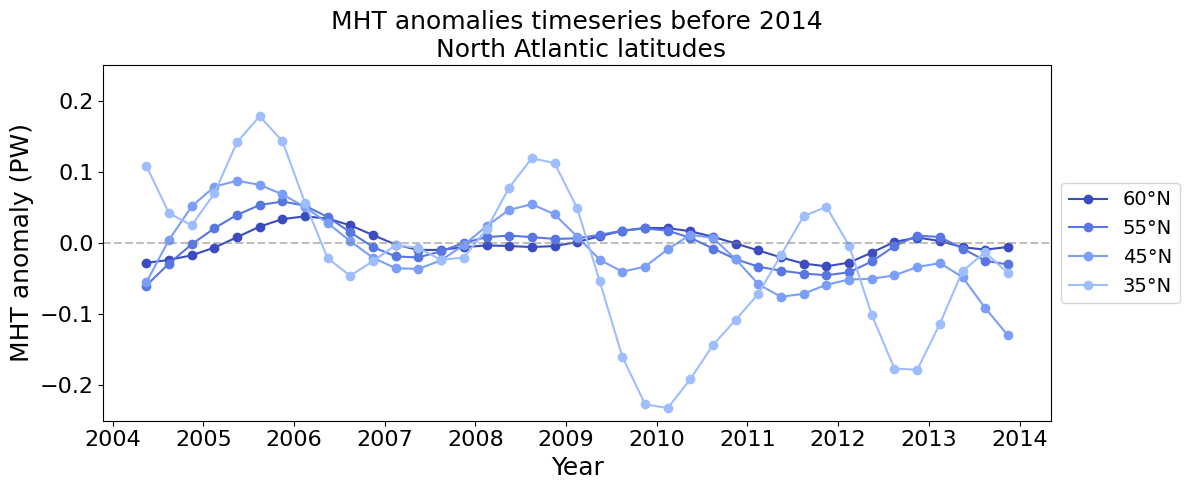

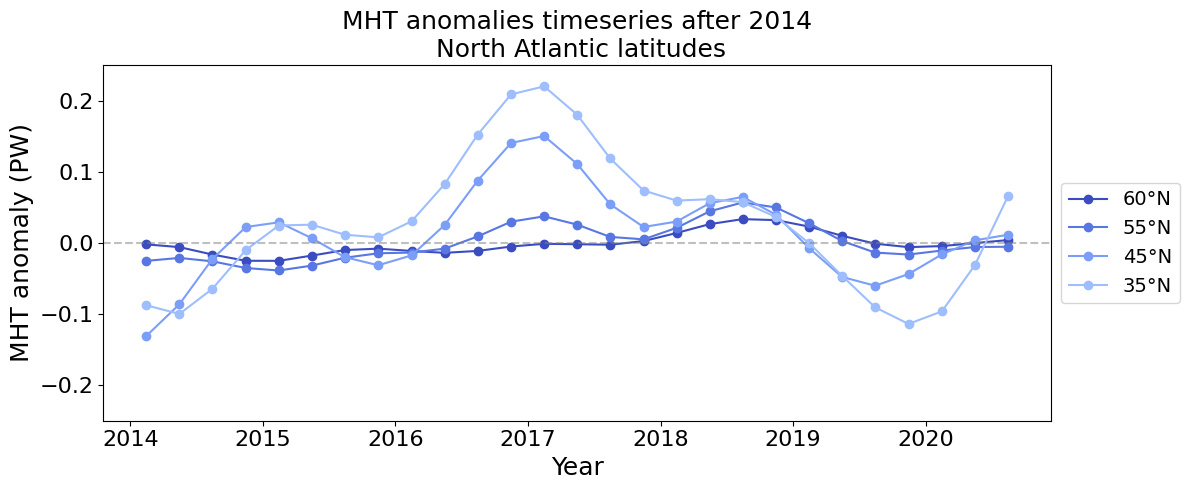

In [ ]:

plot_timeseries(mht_anom_before_2014, northern_lats_high, all_lats=lats, labels=label_map,  colors=colors, label="before 2014\n North Atlantic", savefig=saving, ylim=(-0.25, 0.25))
plot_timeseries(mht_anom_2014, northern_lats_high, all_lats=lats, labels=label_map,  colors=colors, label="after 2014\n North Atlantic", savefig=saving,ylim=(-0.25, 0.25))


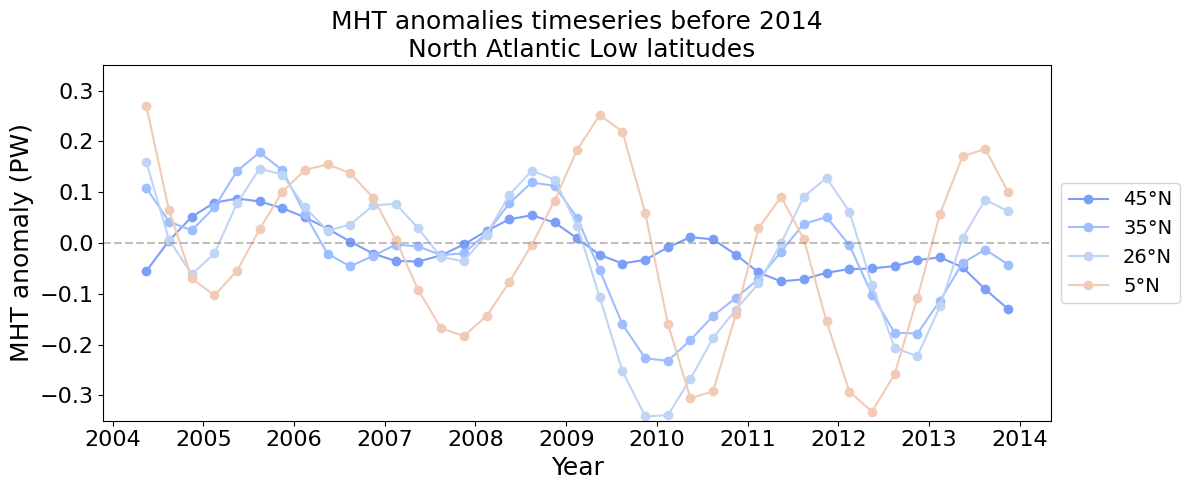

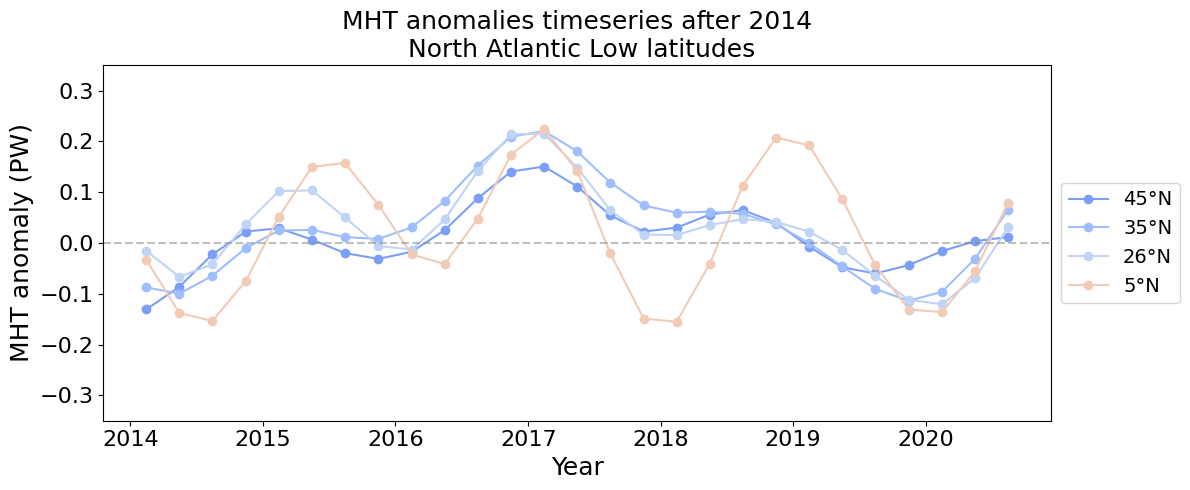

In [ ]:

plot_timeseries(mht_anom_before_2014, northern_lats_low, all_lats=lats, labels=label_map,  colors=colors, label="before 2014\n North Atlantic Low", savefig=saving, ylim=(-0.35, 0.35))
plot_timeseries(mht_anom_2014, northern_lats_low, all_lats=lats, labels=label_map,  colors=colors, label="after 2014\n North Atlantic Low", savefig=saving,ylim=(-0.35, 0.35))


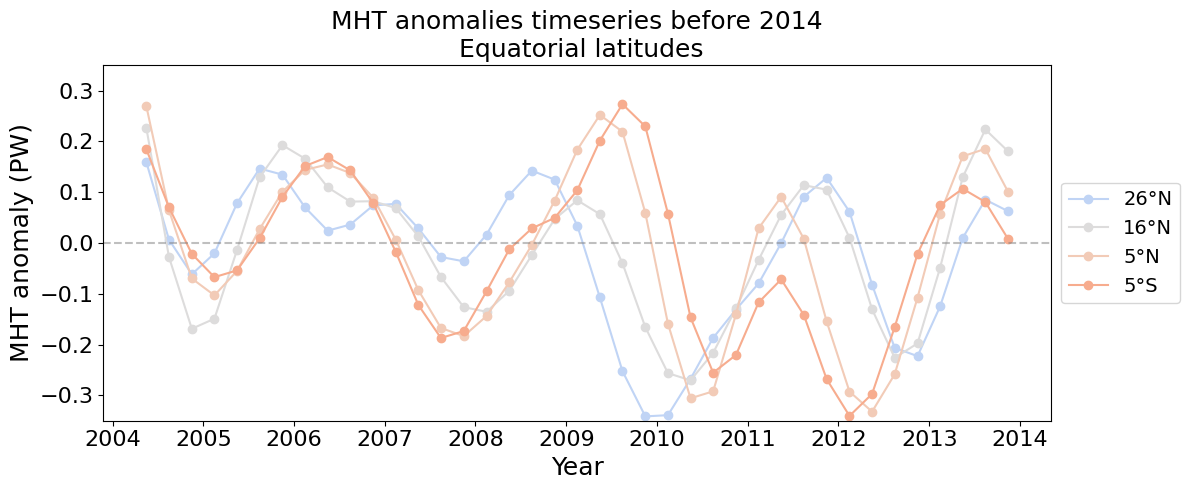

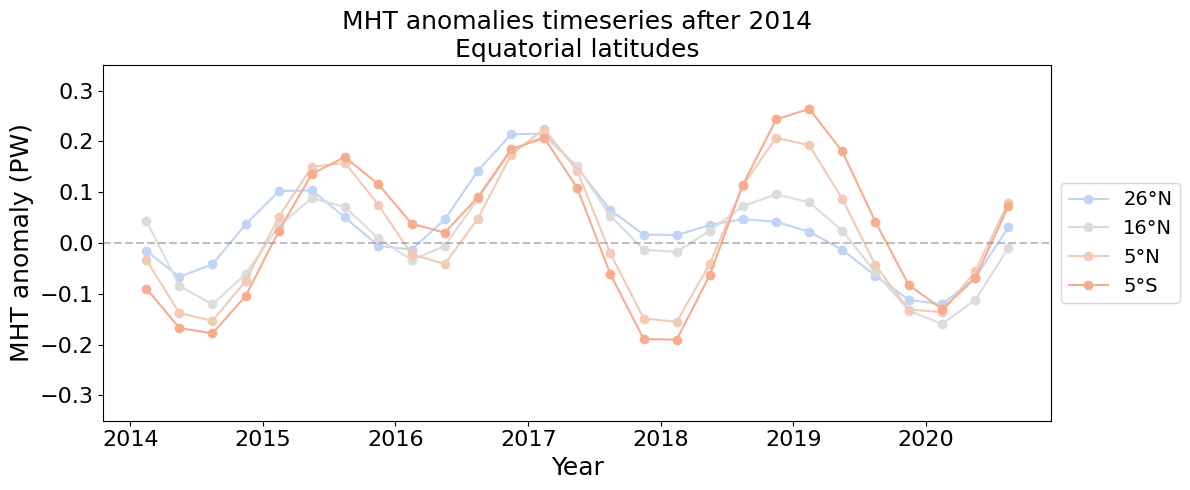

In [ ]:

plot_timeseries(mht_anom_before_2014, eq_lats, all_lats=lats, labels=label_map,  colors=colors, label="before 2014\n Equatorial", savefig=saving, ylim=(-0.35, 0.35))
plot_timeseries(mht_anom_2014, eq_lats, all_lats=lats, labels=label_map,  colors=colors, label="after 2014\nEquatorial", savefig=saving,ylim=(-0.35, 0.35))


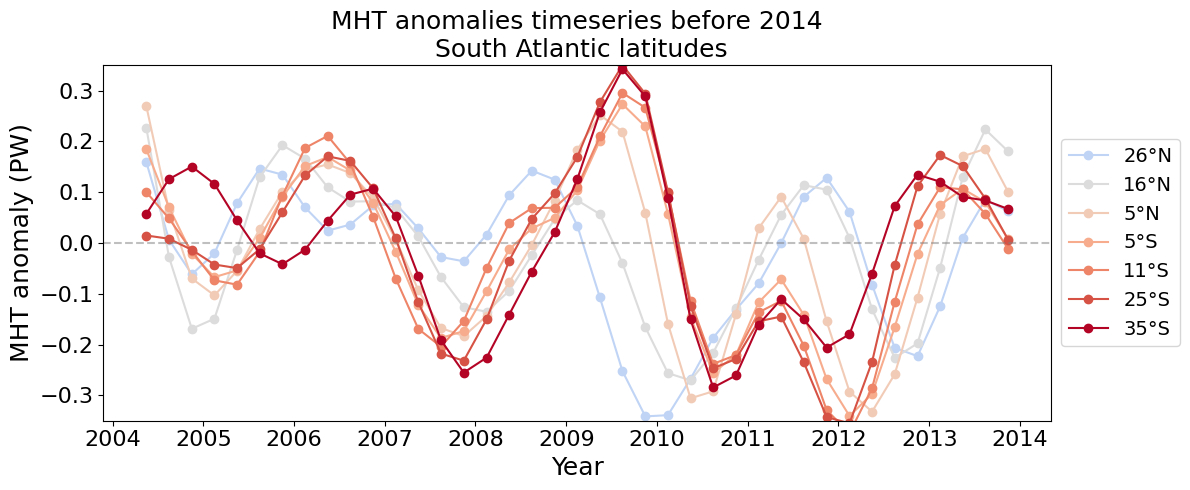

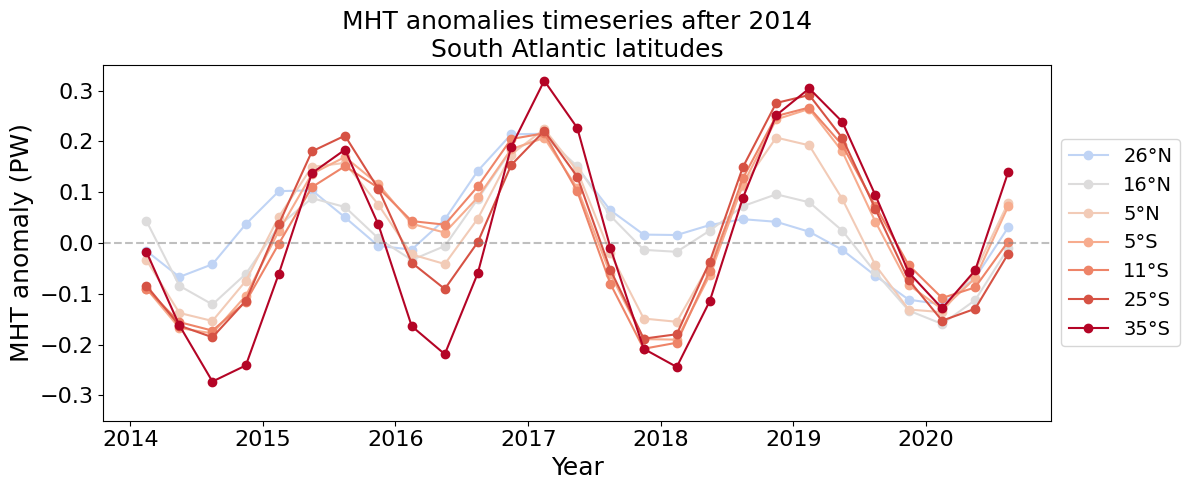

In [ ]:

plot_timeseries(mht_anom_before_2014, southern_lats, all_lats=lats, labels=label_map,  colors=colors, label="before 2014\n South Atlantic", savefig=saving, ylim=(-0.35, 0.35))
plot_timeseries(mht_anom_2014, southern_lats, all_lats=lats, labels=label_map,  colors=colors, label="after 2014\nSouth Atlantic", savefig=saving,ylim=(-0.35, 0.35))


In [ ]:
# plot_timeseries(mht_anom_before_2014, lats, all_lats=lats, labels=label_map,  colors=colors, label="after 2014\nEquatorial", savefig=saving,ylim=(-0.35, 0.35))



=== 45°N vs 26°N ===
  Best by corr: shift=0, corr=0.811, rmsd=0.05 (in percent:18.527 % ), std=0.050
  Best by RMSD:  shift=0.00, rmsd at this shift, )
  Best combo:   shift=0, corr=0.811, std=0.050rmsd=0.052  (in percent:18.527 % ), score=1.000
vmin and vmax for the reference lat 45 here:  -0.13, 0.15
vmin and vmax for the other lat 26 here:  -0.12, 0.21

=== 45°N vs 16°N ===
  Best by corr: shift=-2, corr=0.673, rmsd=0.07 (in percent:23.673 % ), std=0.070
  Best by RMSD:  shift=-2.00, rmsd at this shift, )
  Best combo:   shift=-2, corr=0.673, std=0.070rmsd=0.067  (in percent:23.673 % ), score=1.000
vmin and vmax for the reference lat 45 here:  -0.13, 0.15
vmin and vmax for the other lat 16 here:  -0.16, 0.21

=== 45°N vs -5°N ===
  Best by corr: shift=6, corr=0.611, rmsd=0.10 (in percent:49.569 % ), std=0.121
  Best by RMSD:  shift=-8.00, rmsd at this shift, )
  Best combo:   shift=-8, corr=0.514, std=0.121rmsd=0.099  (in percent:35.351 % ), score=0.960
vmin and vmax for the refer

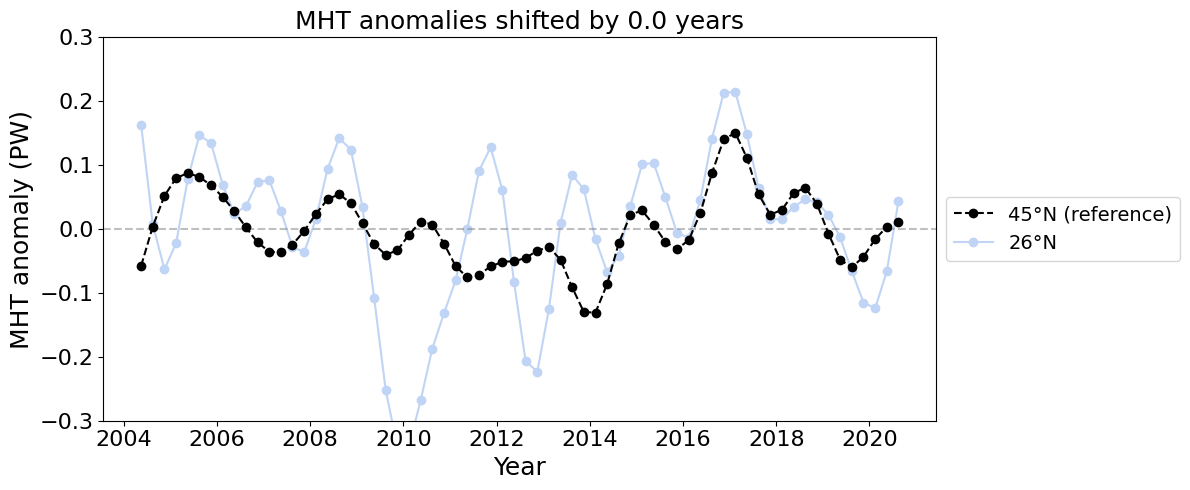


Plotting 16°N with best shift = -2 (-0.50 yrs)
Correlation between 45°N and 16°N with a shift of -0.5 years: 0.48


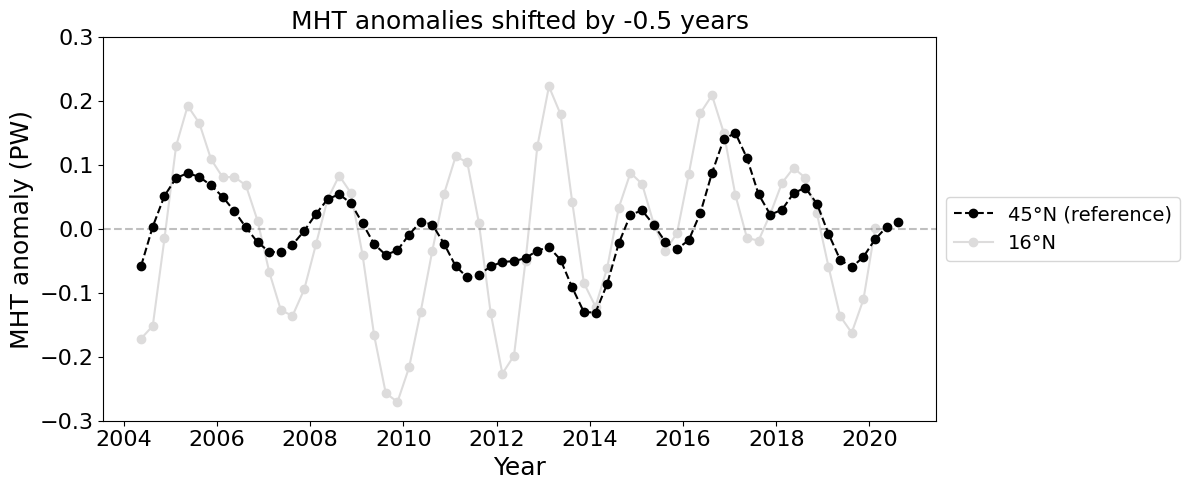


Plotting -5°N with best shift = -8 (-2.00 yrs)
Correlation between 45°N and 5°S with a shift of -2.0 years: -0.00


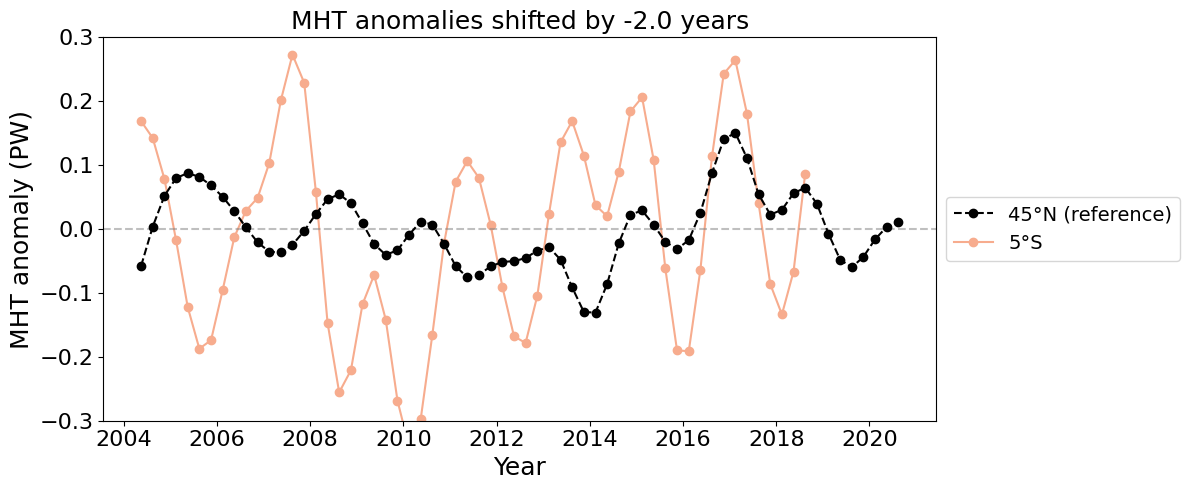

In [ ]:
# lats_to_check= [60]
# lats_to_check = [45, 35] # NA high
# lats_to_check = [26, 5] #NA low
ds_2014 = mht_anom_2014
# ds = mht_anom_before_2014
lats_to_check = [26, 16, -5] #Equator

ref_lat = 45

shift_vals = np.arange(-12, 13, 2)  # -3 to +3 years in steps of 0.5

best_shifts, best_shifts_rmsd, best_shifts_combo, rmsd = find_best_shift(ds_2014, ref_lat, lats_to_check, lags=shift_vals, printout=True)

for lat, best_shift in best_shifts_combo.items():
    print(f"\nPlotting {lat}°N with best shift = {best_shift} ({best_shift/4:.2f} yrs)")
    plot_shifted_timeseries(
        ds,
        ref_lat=ref_lat,
        lats=[lat],
        all_lats=lats,
        lat_labels=label_map,
        colors=colors,
        timedelta=best_shift,
        label=f"{ref_lat}_{lat}N_bestshift",
        savefig=saving,
        ylim=(-0.3, 0.3)
    )